In [39]:
import numpy as np
import pandas as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


In [40]:
file2 = "455 Data.xlsx"

In [41]:
import pandas as pd


In [42]:
pip install Openpyxl

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.


In [43]:
import openpyxl

In [44]:
from openpyxl import load_workbook

In [45]:
pip install pandas openpyxl

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.


In [46]:
file2 = "455 Data.xlsx"

In [47]:
import os

In [48]:
data2 = pd.ExcelFile(file2)

In [49]:
import pandas as pd

In [50]:
df=pd.read_excel("455 Data.xlsx")
df.columns = df.columns.str.strip()
df = df.reset_index(drop=True)
df.head(5)

,Age,Experience,City,Family,CCAvg,Education,Mortgage,Personal.Loan,Securities.Account,CD.Account,Online,CreditCard,Median Income Per City,Income / Median in city
0,-1.774239,-1.665912,PASADENA,1.397274,-0.193366,-1.048973,-0.555468,0,1,0,0,0,-0.410787,-0.415230
1,-0.029521,-0.096321,LOS ANGELES,0.525938,-0.250586,-1.048973,-0.555468,0,1,0,0,0,-0.880547,-0.559558
2,-0.552936,-0.445119,BERKELEY,-1.216733,-0.536683,-1.048973,-0.555468,0,0,0,0,0,-0.079161,-1.185660
3,-0.901880,-0.968316,SAN FRANCISCO,-1.216733,0.436047,0.141689,-0.555468,0,0,0,0,0,0.882823,-0.073356
4,-0.901880,-1.055515,NORTHRIDGE,1.397274,-0.536683,0.141689,-0.555468,0,0,0,0,1,-0.574035,-0.433551


In [51]:
print(df.describe())

                Age    Experience        Family         CCAvg    Education  \
count  5.000000e+03  5.000000e+03  5.000000e+03  5.000000e+03  5000.000000   
mean  -3.552714e-18 -1.186606e-16  1.229239e-16 -3.007017e-15     0.000000   
std    1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00     1.000000   
min   -1.948711e+00 -2.014710e+00 -1.216733e+00 -1.108877e+00    -1.048973   
25%   -9.018800e-01 -8.811162e-01 -1.216733e+00 -7.083407e-01    -1.048973   
50%   -2.952064e-02 -9.121069e-03 -3.453975e-01 -2.505855e-01     0.141689   
75%    8.428387e-01  8.628741e-01  5.259383e-01  3.216085e-01     1.332351   
max    1.889670e+00  1.996468e+00  1.397274e+00  4.613064e+00     1.332351   

           Mortgage  Personal.Loan  Securities.Account  CD.Account  \
count  5.000000e+03    5000.000000         5000.000000  5000.00000   
mean  -5.684342e-17       0.096000            0.104400     0.06040   
std    1.000000e+00       0.294621            0.305809     0.23825   
min   -5.554684e-

<Axes: title={'center': 'Experience'}, ylabel='Frequency'>

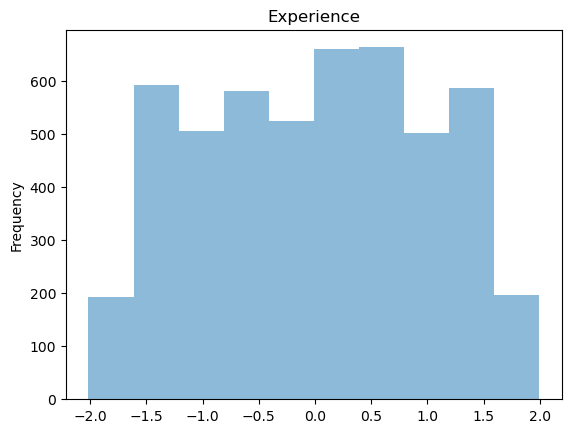

In [52]:
plt.figure(1)
df['Experience'].plot(kind='hist',title='Experience',alpha=0.5)

In [53]:
print(df.dtypes)

Age                        float64
Experience                 float64
City                        object
Family                     float64
CCAvg                      float64
Education                  float64
Mortgage                   float64
Personal.Loan                int64
Securities.Account           int64
CD.Account                   int64
Online                       int64
CreditCard                   int64
Median Income Per City     float64
Income / Median in city    float64
dtype: object


In [54]:
print(list(df.columns))

['Age', 'Experience', 'City', 'Family', 'CCAvg', 'Education', 'Mortgage', 'Personal.Loan', 'Securities.Account', 'CD.Account', 'Online', 'CreditCard', 'Median Income Per City', 'Income / Median in city']


In [55]:
X = df[['Age', 'Experience', 'City', 'Family', 'CCAvg', 'Education', 'Mortgage', 'Personal.Loan', 'Securities.Account', 'CD.Account', 'Online', 'CreditCard', 'Median Income Per City', 'Income / Median in city']]
print(X.head(5))

        Age  Experience           City    Family     CCAvg  Education  \
0 -1.774239   -1.665912       PASADENA  1.397274 -0.193366  -1.048973   
1 -0.029521   -0.096321    LOS ANGELES  0.525938 -0.250586  -1.048973   
2 -0.552936   -0.445119       BERKELEY -1.216733 -0.536683  -1.048973   
3 -0.901880   -0.968316  SAN FRANCISCO -1.216733  0.436047   0.141689   
4 -0.901880   -1.055515     NORTHRIDGE  1.397274 -0.536683   0.141689   

   Mortgage  Personal.Loan  Securities.Account  CD.Account  Online  \
0 -0.555468              0                   1           0       0   
1 -0.555468              0                   1           0       0   
2 -0.555468              0                   0           0       0   
3 -0.555468              0                   0           0       0   
4 -0.555468              0                   0           0       0   

   CreditCard  Median Income Per City  Income / Median in city  
0           0               -0.410787                -0.415230  
1         

In [56]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples,silhouette_score

In [57]:
%matplotlib inline
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as clrs

In [58]:
df['City'] = df['City'].astype('category').cat.codes
X = df[['Age', 'Experience', 'City', 'Family', 'CCAvg', 'Education', 'Mortgage', 'Personal.Loan', 'Securities.Account', 'CD.Account', 'Online', 'CreditCard', 'Median Income Per City', 'Income / Median in city']]

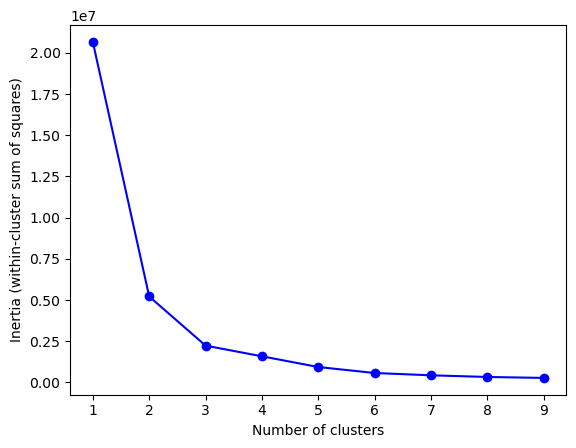

In [59]:
Ks = range(1, 10)
inertia = [KMeans(i).fit(X).inertia_ for i in Ks]

fig = plt.figure()
plt.plot(Ks, inertia, '-bo')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia (within-cluster sum of squares)')
plt.show()

In [60]:
k=2
kmeans = KMeans(n_clusters=k, random_state=1)
kmeans.fit(X)

# print inertia & cluster center
print("inertia for k=2 is", kmeans.inertia_)
print("cluster centers: ", kmeans.cluster_centers_)

# take a quick look at the result
y = kmeans.labels_
print("cluster labels: ", y)

inertia for k=2 is 5215837.24278541
cluster centers:  [[-5.75690340e-04 -1.30318172e-03  1.79662069e+02 -1.35554492e-02
  -5.05288526e-03  1.34987285e-02  1.57949457e-02  9.73180077e-02
   1.09578544e-01  6.32183908e-02  5.95402299e-01  2.92337165e-01
   5.32864262e-02 -3.16111343e-02]
 [ 6.28682756e-04  1.42313987e-03  6.83744770e+01  1.48032311e-02
   5.51800441e-03 -1.47412893e-02 -1.72488738e-02  9.45606695e-02
   9.87447699e-02  5.73221757e-02  5.98326360e-01  2.95815900e-01
  -5.81914529e-02  3.45209458e-02]]
cluster labels:  [0 1 1 ... 0 1 1]


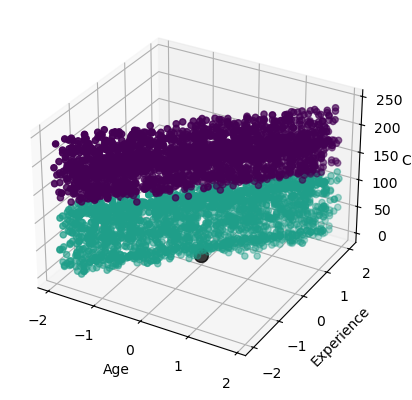

In [118]:
norm = clrs.Normalize(vmin=0.,vmax=y.max() + 0.8)
cmap = cm.viridis

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X.iloc[:,0], X.iloc[:,1], X.iloc[:,2], c=cmap(norm(y)), marker='o')

centers = kmeans.cluster_centers_
ax.scatter(centers[:, 0], centers[:, 1], c='black', s=100, alpha=0.5)

ax.set_xlabel('Age')
ax.set_ylabel('Experience')
ax.set_zlabel('City')

plt.show()

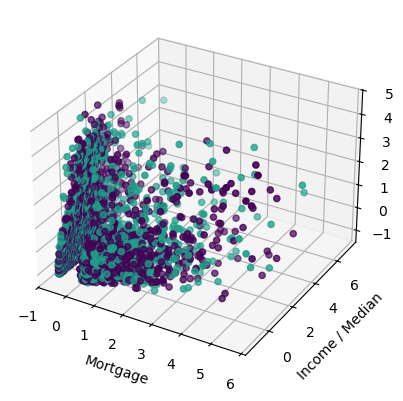

In [124]:
norm = clrs.Normalize(vmin=0.,vmax=y.max() + 0.8)
cmap = cm.viridis

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X.iloc[:,6], X.iloc[:,13], X.iloc[:,4], c=cmap(norm(y)), marker='o')

centers = kmeans.cluster_centers_
ax.scatter(centers[:, 0], centers[:, 1], c='black', s=100, alpha=0.5)

ax.set_xlabel('Mortgage')
ax.set_ylabel('Income / Median')
ax.set_zlabel('CCAvg')

plt.show()

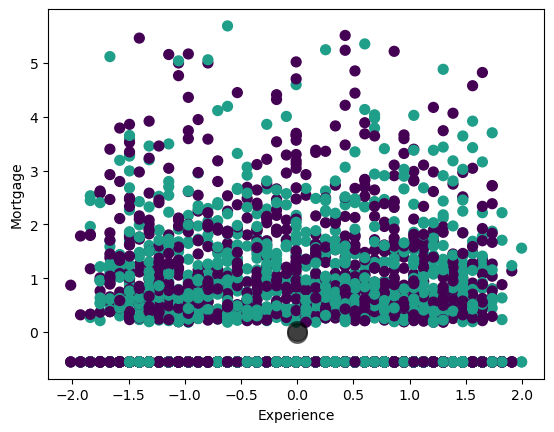

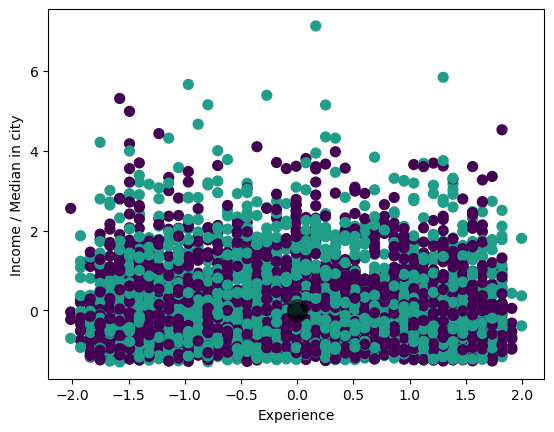

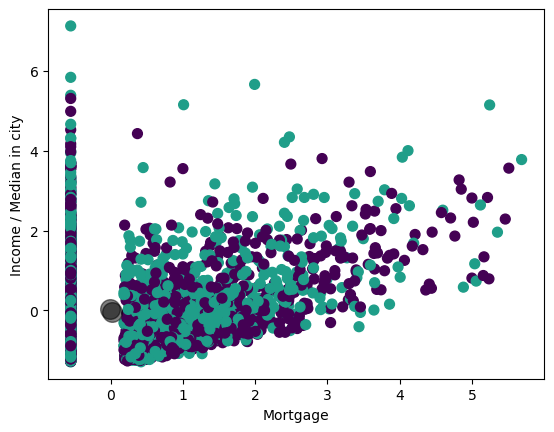

In [62]:
%matplotlib inline
import matplotlib.pyplot as plt

figs = [(1, 6), (1, 13), (6, 13)]
labels = ['Education', 'Mortgage', 'Income / Median in City']
axis_labels = {1: 'Experience', 6: 'Mortgage', 13: 'Income / Median in city'}

for i in range(3):
    fig = plt.figure(i)
    plt.scatter(X.iloc[:,figs[i][0]], X.iloc[:,figs[i][1]], c=cmap(norm(y)), s=50)
    plt.scatter(centers[:, figs[i][0]], centers[:, figs[i][1]], c='black', s=200, alpha=0.5)
    plt.xlabel(axis_labels[figs[i][0]])
    plt.ylabel(axis_labels[figs[i][1]])

plt.show()

In [63]:
range_n_clusters=[2,3,4,5,6,7,8,9,10]
for n_clusters in range_n_clusters:
    clusterer=KMeans(n_clusters=n_clusters, random_state=1)
    cluster_labels=clusterer.fit_predict(X)
    silhouette_avg=silhouette_score(X,cluster_labels)
    print("For n_clusters=", n_clusters,
          "The average silhouette_score is :", silhouette_avg)

For n_clusters= 2 The average silhouette_score is : 0.6366252304965703
For n_clusters= 3 The average silhouette_score is : 0.6200512376231054
For n_clusters= 4 The average silhouette_score is : 0.5802393551618483
For n_clusters= 5 The average silhouette_score is : 0.5570633117977957
For n_clusters= 6 The average silhouette_score is : 0.5940985705226122
For n_clusters= 7 The average silhouette_score is : 0.5322121487062385
For n_clusters= 8 The average silhouette_score is : 0.5810942827169474
For n_clusters= 9 The average silhouette_score is : 0.5596007318783571
For n_clusters= 10 The average silhouette_score is : 0.5558209006958945


In [64]:
from sklearn.cluster import \
(KMeans,
AgglomerativeClustering)

In [65]:
from scipy.cluster.hierarchy import \
(dendrogram,
cut_tree)

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram


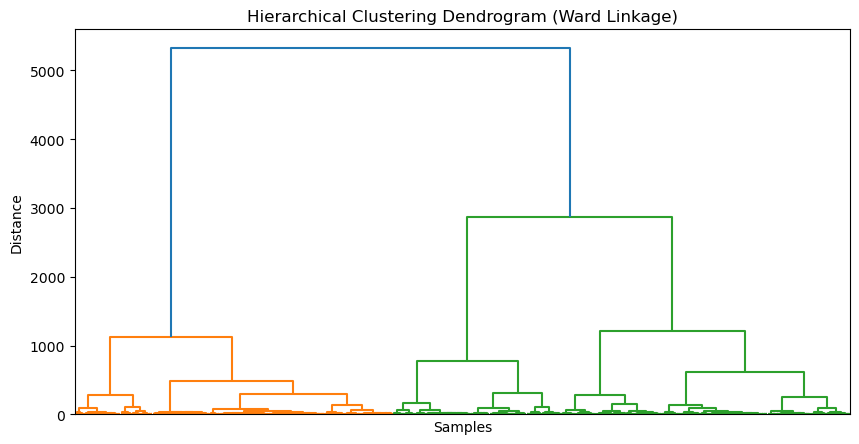

In [67]:
Z = linkage(X, method="ward")
plt.figure(figsize=(10, 5))
dendrogram(Z, no_labels=True)
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

In [68]:
k_values = list(range(2, 7))
sil_scores = []
for k in k_values:
    model = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels_k = model.fit_predict(X)
    sil = silhouette_score(X, labels_k)
    sil_scores.append(sil)

best_k = k_values[int(np.argmax(sil_scores))]
print(f"Optimal k = {best_k}, Silhouette Score = {max(sil_scores):.3f}")

Optimal k = 3, Silhouette Score = 0.614


In [69]:
final_model = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
labels_final = final_model.fit_predict(X)

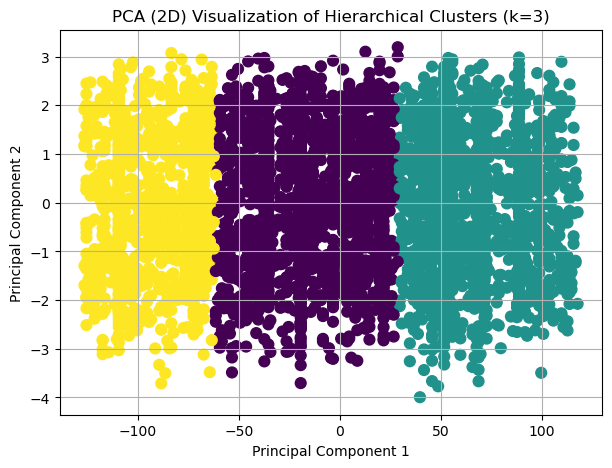

In [70]:
#Visualization 
pca = PCA(n_components=2, random_state=42)
X2 = pca.fit_transform(X)

plt.figure(figsize=(7, 5))
plt.scatter(X2[:, 0], X2[:, 1], c=labels_final, s=60)
plt.title(f"PCA (2D) Visualization of Hierarchical Clusters (k={best_k})")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

In [71]:
import numpy as np
import matplotlib.pyplot as plt

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [75]:
c = 2          # number of clusters (try 2 or 3)
m = 1.5        # fuzziness
error = 1e-5   # stop threshold
maxiter = 300

In [76]:
!pip install scikit-fuzzy
import skfuzzy as fuzz
data = X.T
cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    data=data, c=c, m=m, error=error, maxiter=maxiter, init=None, seed=42)

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [77]:
hard_labels = np.argmax(u, axis=0)

In [78]:
print(f"FPC (higher better, ≤1): {fpc:.4f}")

FPC (higher better, ≤1): 0.9420


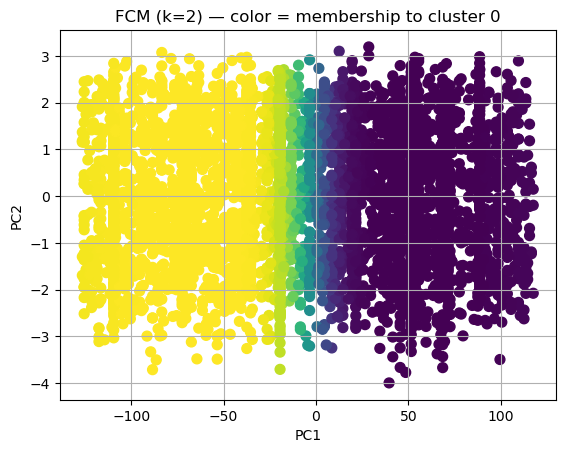

In [81]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X2 = pca.fit_transform(X)

plt.figure()
plt.scatter(X2[:,0], X2[:,1], c=u[0], s=50)
plt.title(f"FCM (k={c}) — color = membership to cluster 0")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.grid(True)
plt.show()

In [83]:
c = 2          # number of clusters (try 2 or 3)
m = 3        # fuzziness
error = 1e-5   # stop threshold
maxiter = 300

In [84]:
!pip install scikit-fuzzy
import skfuzzy as fuzz
data = X.T
cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    data=data, c=c, m=m, error=error, maxiter=maxiter, init=None, seed=42)

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [85]:
hard_labels = np.argmax(u, axis=0)

In [86]:
print(f"FPC (higher better, ≤1): {fpc:.4f}")

FPC (higher better, ≤1): 0.7256


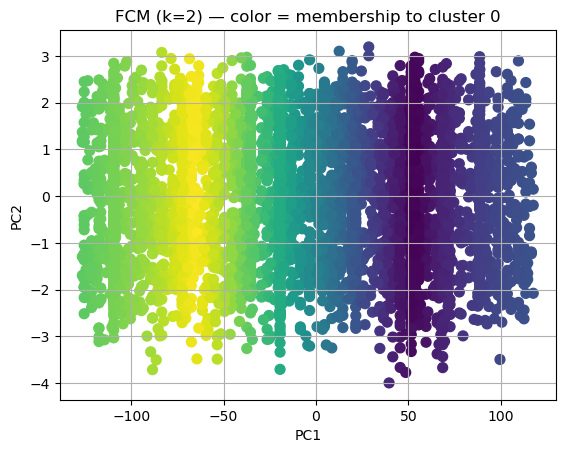

In [87]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X2 = pca.fit_transform(X)

plt.figure()
plt.scatter(X2[:,0], X2[:,1], c=u[0], s=50)
plt.title(f"FCM (k={c}) — color = membership to cluster 0")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.grid(True)
plt.show()

In [125]:
c = 3          # number of clusters (try 2 or 3)
m = 1.5        # fuzziness
error = 1e-5   # stop threshold
maxiter = 300

In [126]:
!pip install scikit-fuzzy
import skfuzzy as fuzz
data = X.T
cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    data=data, c=c, m=m, error=error, maxiter=maxiter, init=None, seed=42)

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [127]:
hard_labels = np.argmax(u, axis=0)

In [128]:
print(f"FPC (higher better, ≤1): {fpc:.4f}")

FPC (higher better, ≤1): 0.9347


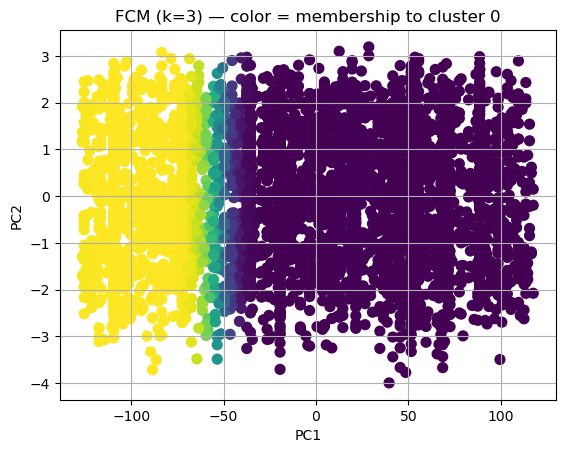

In [132]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X2 = pca.fit_transform(X)

plt.figure()
plt.scatter(X2[:,0], X2[:,1], c=u[0], s=50)
plt.title(f"FCM (k={c}) — color = membership to cluster 0")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.grid(True)
plt.show()